# Breast Cancer Classification using SVM
Using the Wisconsin Breast Cancer dataset to train and evaluate an SVM classifier, then compare with logistic regression.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
cols = [
    "id", "thickness", "size", "shape",
    "adhesion", "epithelial",
    "nuclei", "chromatin",
    "nucleoli", "mitosis", "class_label"
]
df = pd.read_csv("breast-cancer-wisconsin.data", names=cols)
df.head()

,id,thickness,size,shape,adhesion,epithelial,nuclei,chromatin,nucleoli,mitosis,class_label
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [3]:
# The nuclei column has some '?' values, replacing them with NaN and dropping those rows
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)
df = df.astype(float)
df.drop("id", axis=1, inplace=True)

# Map class labels: 2 = benign (0), 4 = malignant (1)
df["class_label"] = df["class_label"].map({2: 0, 4: 1})
df.head()

,thickness,size,shape,adhesion,epithelial,nuclei,chromatin,nucleoli,mitosis,class_label
0,5.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,0
1,5.0,4.0,4.0,5.0,7.0,10.0,3.0,2.0,1.0,0
2,3.0,1.0,1.0,1.0,2.0,2.0,3.0,1.0,1.0,0
3,6.0,8.0,8.0,1.0,3.0,4.0,3.0,7.0,1.0,0
4,4.0,1.0,1.0,3.0,2.0,1.0,3.0,1.0,1.0,0


In [4]:
X = df.drop("class_label", axis=1)
y = df["class_label"]

# 80/20 split, stratify to keep class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Step 1: Hyperparameter Search
Try different kernels and C values to find the best combination using 5-fold cross-validated balanced accuracy on the training set.

In [5]:
kernels = ['linear', 'rbf', 'poly']
C_values = [0.1, 1, 10, 100]
results = []

for k in kernels:
    for c in C_values:
        model = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel=k, C=c))])
        score = cross_val_score(model, X_train, y_train, cv=5, scoring='balanced_accuracy').mean()
        print(k, c, round(score, 4))
        results.append((k, c, score))

best_kernel, best_C, best_score = max(results, key=lambda x: x[2])
print(f"\nBest config: kernel={best_kernel}, C={best_C}, CV balanced accuracy={best_score:.4f}")

linear 0.1 0.9664
linear 1 0.9626
linear 10 0.9652
linear 100 0.9652
rbf 0.1 0.9674
rbf 1 0.9662
rbf 10 0.9491
rbf 100 0.9399
poly 0.1 0.8964
poly 1 0.9356
poly 10 0.9511
poly 100 0.947

Best config: kernel=rbf, C=0.1, CV balanced accuracy=0.9674


## Step 2: Train Final SVM with Best Hyperparameters
Using the best kernel and C found above, train on the full training set and evaluate on the held-out test set.

In [6]:
# Using best_kernel and best_C from the search above
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel=best_kernel, C=best_C))
])

svm_cv_scores = cross_val_score(svm_model, X_train, y_train, cv=5, scoring='balanced_accuracy')
print("5-fold CV balanced accuracy (SVM):", round(svm_cv_scores.mean(), 4))

5-fold CV balanced accuracy (SVM): 0.9674


Test balanced accuracy (SVM): 0.9671


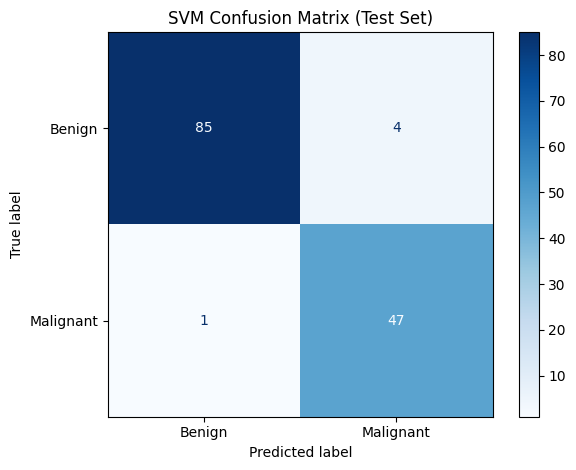

In [7]:
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

svm_test_acc = balanced_accuracy_score(y_test, y_pred)
print("Test balanced accuracy (SVM):", round(svm_test_acc, 4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap='Blues')
plt.title("SVM Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

## Step 3: Logistic Regression (without basis functions)

In [8]:
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

log_scores = cross_val_score(log_model, X_train, y_train, cv=5, scoring='balanced_accuracy')
print("5-fold CV balanced accuracy (Logistic Regression):", round(log_scores.mean(), 4))

5-fold CV balanced accuracy (Logistic Regression): 0.9654


## Step 4: Logistic Regression with Polynomial Basis Functions (degree=2)

In [9]:
poly_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2)),
    ("logreg", LogisticRegression(max_iter=2000))
])

poly_scores = cross_val_score(poly_model, X_train, y_train, cv=5, scoring='balanced_accuracy')
print("5-fold CV balanced accuracy (Logistic + Polynomial):", round(poly_scores.mean(), 4))

5-fold CV balanced accuracy (Logistic + Polynomial): 0.9586


## Summary: Model Comparison

In [10]:
print("Model Comparison (5-fold CV Balanced Accuracy on Training Set)")
print("-" * 55)
print(f"SVM (kernel={best_kernel}, C={best_C}):         {svm_cv_scores.mean():.4f}")
print(f"Logistic Regression:                  {log_scores.mean():.4f}")
print(f"Logistic Regression + Poly (deg=2):   {poly_scores.mean():.4f}")
print("-" * 55)
print(f"SVM Test Balanced Accuracy:           {svm_test_acc:.4f}")

Model Comparison (5-fold CV Balanced Accuracy on Training Set)
-------------------------------------------------------
SVM (kernel=rbf, C=0.1):         0.9674
Logistic Regression:                  0.9654
Logistic Regression + Poly (deg=2):   0.9586
-------------------------------------------------------
SVM Test Balanced Accuracy:           0.9671
